In [1]:
import cv2
import numpy as np
from PIL import Image
from diffusers.utils import load_image

original_image = load_image(
    "https://i.pinimg.com/1200x/9f/8c/a8/9f8ca82a0dacee57a9ff3f8497531e60.jpg"
    #"https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/non-enhanced-prompt.png"
)
'''
image = np.array(original_image)

low_threshold = 100
high_threshold = 200

image = cv2.Canny(image, low_threshold, high_threshold)
image = image[:, :, None]
image = np.concatenate([image, image, image], axis=2)
canny_image = Image.fromarray(image)
'''

'\nimage = np.array(original_image)\n\nlow_threshold = 100\nhigh_threshold = 200\n\nimage = cv2.Canny(image, low_threshold, high_threshold)\nimage = image[:, :, None]\nimage = np.concatenate([image, image, image], axis=2)\ncanny_image = Image.fromarray(image)\n'

In [2]:
#für depth map
import torch
import numpy as np
from PIL import Image
from transformers import DPTImageProcessor, DPTForDepthEstimation
from diffusers import ControlNetModel, StableDiffusionXLControlNetImg2ImgPipeline, AutoencoderKL
from diffusers.utils import load_image


depth_estimator = DPTForDepthEstimation.from_pretrained("Intel/dpt-hybrid-midas").to("cuda")
feature_extractor = DPTImageProcessor.from_pretrained("Intel/dpt-hybrid-midas")

def get_depth_map(image):
    image = feature_extractor(images=image, return_tensors="pt").pixel_values.to("cuda")
    with torch.no_grad(), torch.autocast("cuda"):
        depth_map = depth_estimator(image).predicted_depth

    depth_map = torch.nn.functional.interpolate(
        depth_map.unsqueeze(1),
        size=(1024, 1024),
        mode="bicubic",
        align_corners=False,
    )
    depth_min = torch.amin(depth_map, dim=[1, 2, 3], keepdim=True)
    depth_max = torch.amax(depth_map, dim=[1, 2, 3], keepdim=True)
    depth_map = (depth_map - depth_min) / (depth_max - depth_min)
    image = torch.cat([depth_map] * 3, dim=1)
    image = image.permute(0, 2, 3, 1).cpu().numpy()[0]
    image = Image.fromarray((image * 255.0).clip(0, 255).astype(np.uint8))
    return image

depth_image = get_depth_map(original_image)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [3]:
#img2img with depth map
controlnet = ControlNetModel.from_pretrained(
    "diffusers/controlnet-depth-sdxl-1.0-small",
    torch_dtype=torch.float16,
)
vae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16)
pipeline = StableDiffusionXLControlNetImg2ImgPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    controlnet=controlnet,
    vae=vae,
    torch_dtype=torch.float16,
).to("cuda")



Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


  0%|          | 0/99 [00:00<?, ?it/s]

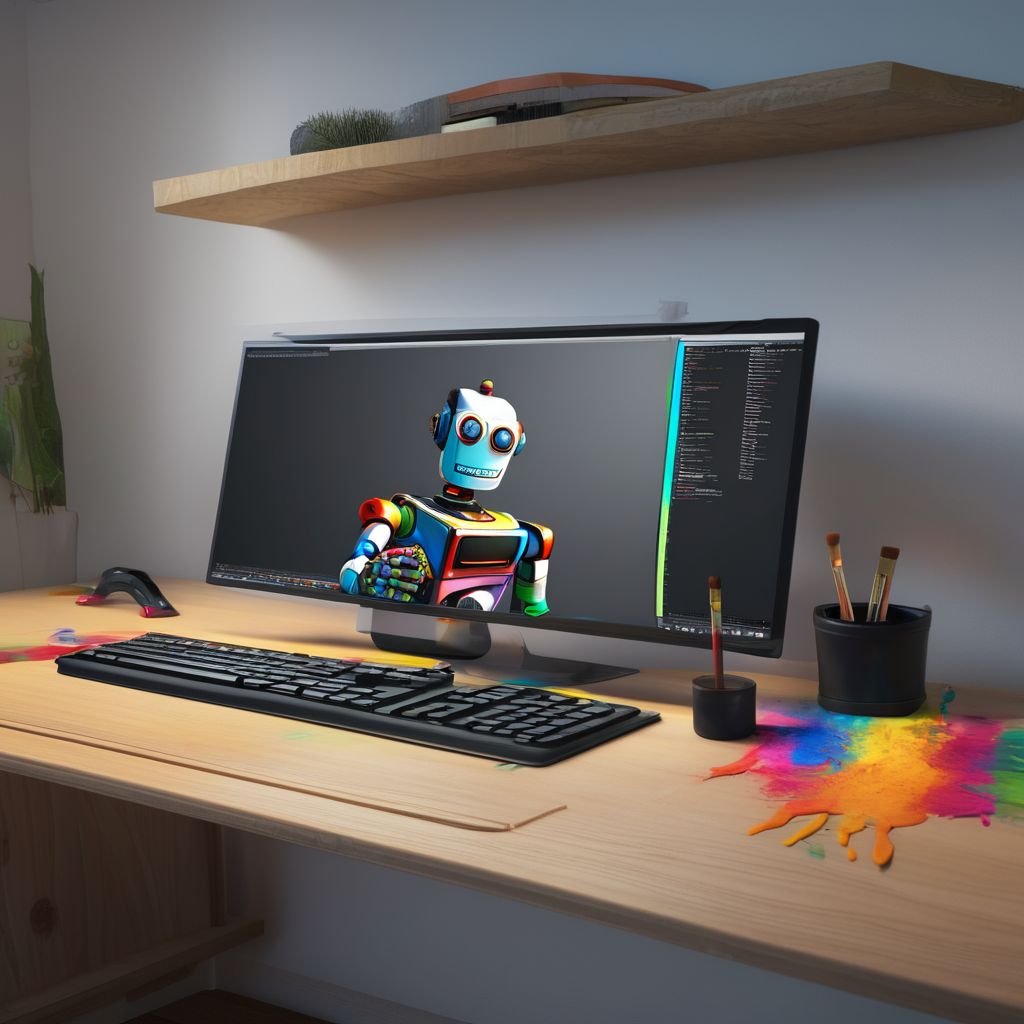

In [10]:
prompt = """
A photorealistic image of a standard computer Monitor with a black keyboard in front, on a wooden desk, with a white wall behind it. 
The Display displays a colorful robot, who is holding a rainbow colored paintbrush in his hand. 
The robot looks directly at the viewer, with the arm with the paintbrush. High detail"""
image = load_image(
    "https://i.pinimg.com/1200x/9f/8c/a8/9f8ca82a0dacee57a9ff3f8497531e60.jpg"
    #"https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/non-enhanced-prompt.png"
).resize((1024, 1024))
controlnet_conditioning_scale = 0.5 
pipeline(
    prompt,
    image=image,
    control_image=depth_image,
    controlnet_conditioning_scale=controlnet_conditioning_scale,
    strength=0.99,
    num_inference_steps=100,
).images[0]

# Images
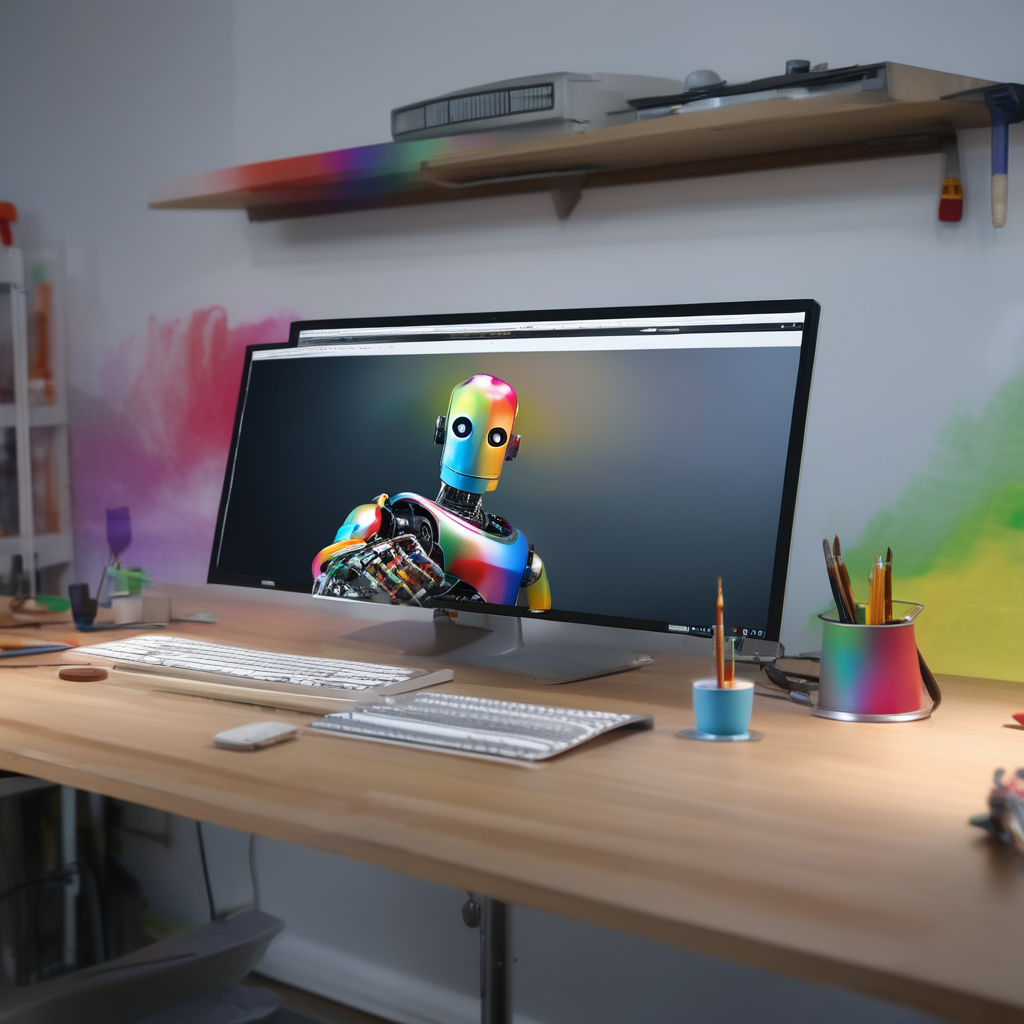

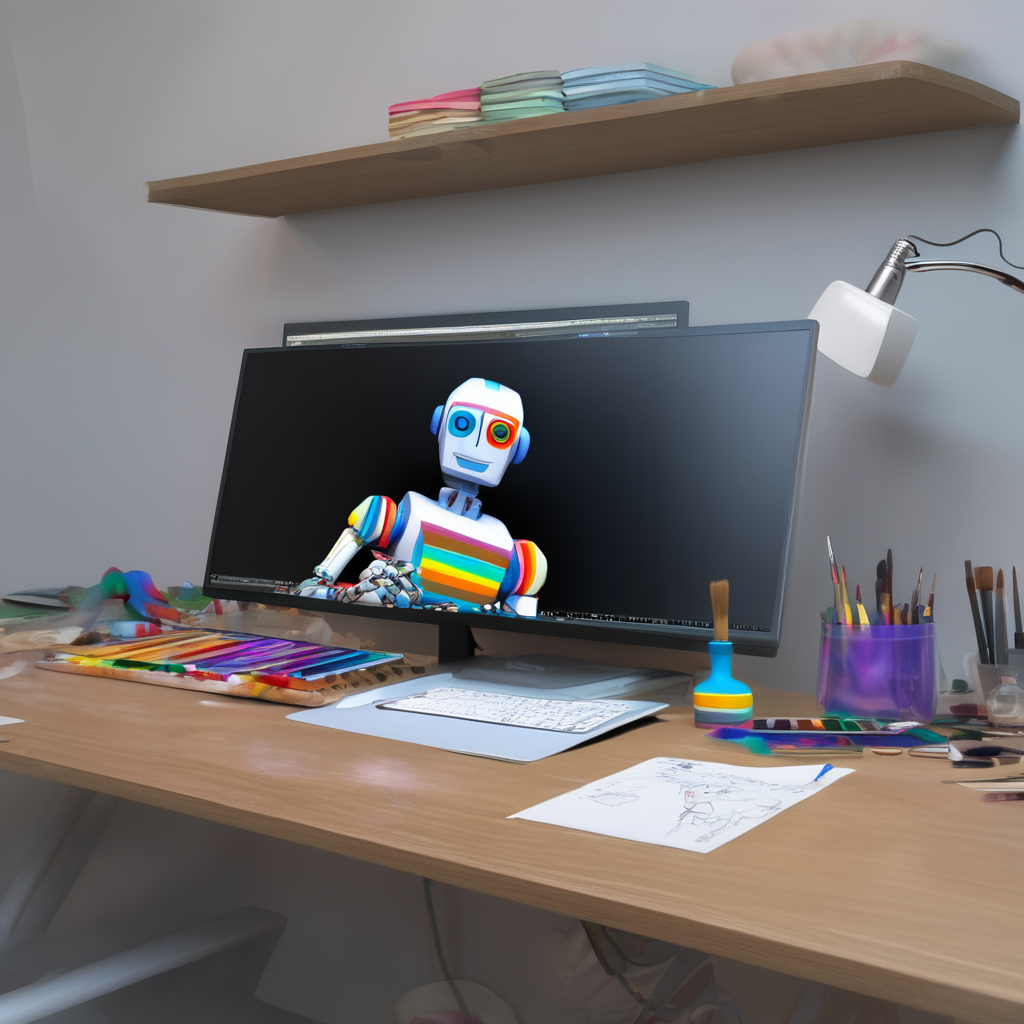

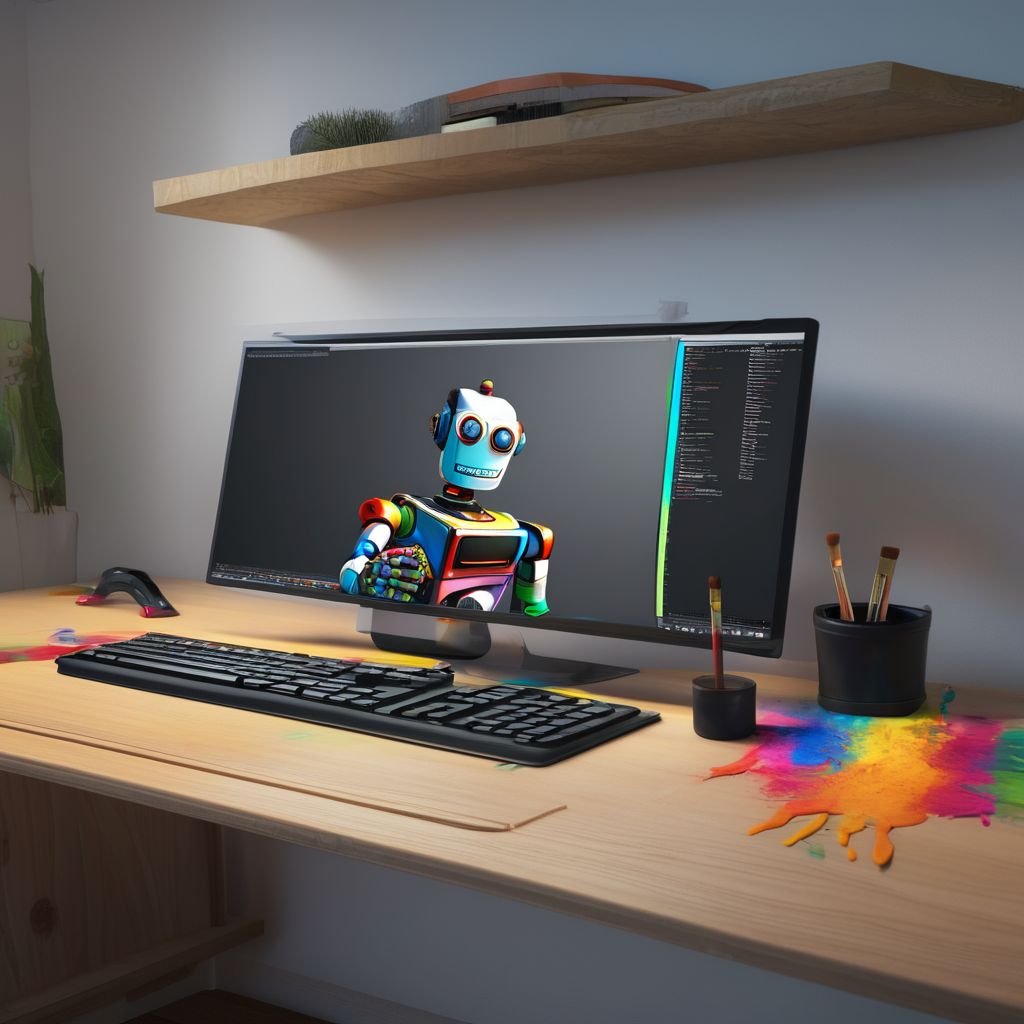

In [5]:
#text-to-image with canny
'''
import torch
from diffusers.utils import load_image
from diffusers import FluxControlNetPipeline, FluxControlNetModel

controlnet = FluxControlNetModel.from_pretrained(
    "InstantX/FLUX.1-dev-Controlnet-Canny", torch_dtype=torch.bfloat16
)
pipeline = FluxControlNetPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-dev", controlnet=controlnet, torch_dtype=torch.bfloat16
).to("cuda")

prompt = """
A photorealistic overhead image of a cat reclining sideways in a flamingo pool floatie holding a margarita. 
The cat is floating leisurely in the pool and completely relaxed and happy.
"""

pipeline(
    prompt, 
    control_image=canny_image,
    controlnet_conditioning_scale=0.5,
    num_inference_steps=50, 
    guidance_scale=3.5,
).images[0]
'''

'\nimport torch\nfrom diffusers.utils import load_image\nfrom diffusers import FluxControlNetPipeline, FluxControlNetModel\n\ncontrolnet = FluxControlNetModel.from_pretrained(\n    "InstantX/FLUX.1-dev-Controlnet-Canny", torch_dtype=torch.bfloat16\n)\npipeline = FluxControlNetPipeline.from_pretrained(\n    "black-forest-labs/FLUX.1-dev", controlnet=controlnet, torch_dtype=torch.bfloat16\n).to("cuda")\n\nprompt = """\nA photorealistic overhead image of a cat reclining sideways in a flamingo pool floatie holding a margarita. \nThe cat is floating leisurely in the pool and completely relaxed and happy.\n"""\n\npipeline(\n    prompt, \n    control_image=canny_image,\n    controlnet_conditioning_scale=0.5,\n    num_inference_steps=50, \n    guidance_scale=3.5,\n).images[0]\n'

In [6]:
'''
import torch
from diffusers import StableDiffusionXLControlNetPipeline, ControlNetModel, AutoencoderKL

controlnets = [
    ControlNetModel.from_pretrained(
        "diffusers/controlnet-depth-sdxl-1.0-small", torch_dtype=torch.float16
    ),
    ControlNetModel.from_pretrained(
        "diffusers/controlnet-canny-sdxl-1.0", torch_dtype=torch.float16,
    ),
]

vae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16)
pipeline = StableDiffusionXLControlNetPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", controlnet=controlnets, vae=vae, torch_dtype=torch.float16
).to("cuda")

prompt = """
a relaxed rabbit sitting on a striped towel next to a pool with a tropical drink nearby, 
bright sunny day, vacation scene, 35mm photograph, film, professional, 4k, highly detailed
"""
negative_prompt = "lowres, bad anatomy, worst quality, low quality, deformed, ugly"

images = [canny_image.resize((1024, 1024)), depth_image.resize((1024, 1024))]

pipeline(
    prompt,
    negative_prompt=negative_prompt,
    image=images,
    num_inference_steps=100,
    controlnet_conditioning_scale=[0.5, 0.5],
    strength=0.7,
).images[0]
'''

'\nimport torch\nfrom diffusers import StableDiffusionXLControlNetPipeline, ControlNetModel, AutoencoderKL\n\ncontrolnets = [\n    ControlNetModel.from_pretrained(\n        "diffusers/controlnet-depth-sdxl-1.0-small", torch_dtype=torch.float16\n    ),\n    ControlNetModel.from_pretrained(\n        "diffusers/controlnet-canny-sdxl-1.0", torch_dtype=torch.float16,\n    ),\n]\n\nvae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16)\npipeline = StableDiffusionXLControlNetPipeline.from_pretrained(\n    "stabilityai/stable-diffusion-xl-base-1.0", controlnet=controlnets, vae=vae, torch_dtype=torch.float16\n).to("cuda")\n\nprompt = """\na relaxed rabbit sitting on a striped towel next to a pool with a tropical drink nearby, \nbright sunny day, vacation scene, 35mm photograph, film, professional, 4k, highly detailed\n"""\nnegative_prompt = "lowres, bad anatomy, worst quality, low quality, deformed, ugly"\n\nimages = [canny_image.resize((1024, 1024)), de

In [7]:
'''
import torch
from diffusers import StableDiffusionXLControlNetPipeline, ControlNetModel

controlnet = ControlNetModel.from_pretrained(
  "diffusers/controlnet-canny-sdxl-1.0", torch_dtype=torch.float16
)
pipeline = StableDiffusionXLControlNetPipeline.from_pretrained(
  "stabilityai/stable-diffusion-xl-base-1.0",
  controlnet=controlnet,
  torch_dtype=torch.float16
).to("cuda")

canny_image = load_image("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/canny-cat.png")
pipeline(
  "",
  image=canny_image,
  guess_mode=True
).images[0]
'''

'\nimport torch\nfrom diffusers import StableDiffusionXLControlNetPipeline, ControlNetModel\n\ncontrolnet = ControlNetModel.from_pretrained(\n  "diffusers/controlnet-canny-sdxl-1.0", torch_dtype=torch.float16\n)\npipeline = StableDiffusionXLControlNetPipeline.from_pretrained(\n  "stabilityai/stable-diffusion-xl-base-1.0",\n  controlnet=controlnet,\n  torch_dtype=torch.float16\n).to("cuda")\n\ncanny_image = load_image("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/canny-cat.png")\npipeline(\n  "",\n  image=canny_image,\n  guess_mode=True\n).images[0]\n'